In [ ]:
!pip install transformers datasets sklearn
import os
from transformers import BertConfig, BertForSequenceClassification
import pandas as pd
import torch
from datasets import Dataset
from transformers import BertTokenizerFast, BertForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.model_selection import train_test_split

# Ensure GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Step 1: Load dataset
df = pd.read_csv("multilingual_toxicity.csv")
df = df.dropna(subset=["text", "toxic"])  # Remove missing values
df["toxic"] = df["toxic"].astype(int)  # Ensure labels are integers

# Step 2: Split dataset
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["toxic"])
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Step 3: Load tokenizer and model
model_name = "bert-base-multilingual-cased"
config = BertConfig.from_pretrained(
    model_name,
    hidden_dropout_prob=0.2,  # Increase dropout for fully connected layers
    attention_probs_dropout_prob=0.2  # Increase dropout for attention probabilities
)
model = BertForSequenceClassification.from_pretrained("bert-base-multilingual-cased", config=config).to(device)
# Step 3: Load the tokenizer and model
model_name = "bert-base-multilingual-cased"  # You can replace this with another model if needed
tokenizer = BertTokenizerFast.from_pretrained(model_name)
# Step 4: Tokenize datasets
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

train_tokenized_dataset = train_dataset.map(tokenize_function, batched=True)
test_tokenized_dataset = test_dataset.map(tokenize_function, batched=True)

# Remove unnecessary columns
train_tokenized_dataset = train_tokenized_dataset.remove_columns(["text", "__index_level_0__"])
test_tokenized_dataset = test_tokenized_dataset.remove_columns(["text", "__index_level_0__"])

# Rename labels for Trainer compatibility
train_tokenized_dataset = train_tokenized_dataset.rename_column("toxic", "labels")
test_tokenized_dataset = test_tokenized_dataset.rename_column("toxic", "labels")

# Set format for PyTorch
train_tokenized_dataset.set_format("torch")
test_tokenized_dataset.set_format("torch")

# Step 5: Define metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
    }

# Step 6: Define training arguments with enhancements
training_args = TrainingArguments(
    output_dir="./resultsMain",
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    evaluation_strategy="epoch",  # Evaluate after every epoch
    save_strategy="epoch",  # Save model checkpoint after each epoch
    learning_rate=5e-6,  # Set a smaller learning rate for fine-tuning
    weight_decay=0.01,  # Add weight decay for regularization
    warmup_steps=500,  # Gradually increase learning rate in the first 500 steps
    logging_steps=10,  # Log metrics frequently
    load_best_model_at_end=True,  # Load the best checkpoint
    save_total_limit=2,  # Keep only the last 2 checkpoints
    metric_for_best_model="eval_loss",  # Use validation loss to determine the best model
    greater_is_better=False,  # Smaller validation loss is better
)

# Step 7: Add early stopping callback
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized_dataset,
    eval_dataset=test_tokenized_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],  # Stop if no improvement in 2 epochs
)

# Step 8: Train the model
trainer.train()

# Step 9: Evaluate the model
eval_results = trainer.evaluate()
print("Final Evaluation Results:")
print(f"Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"F1-Score: {eval_results['eval_f1']:.4f}")
print(f"Precision: {eval_results['eval_precision']:.4f}")
print(f"Recall: {eval_results['eval_recall']:.4f}")


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Using device: cuda


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.692500,0.670692,0.656000,0.652091,0.663341,0.656000
2,0.583700,0.536536,0.789000,0.788797,0.790115,0.789000
3,0.408600,0.357894,0.850000,0.849528,0.854446,0.850000
4,0.346200,0.302500,0.875000,0.874985,0.875182,0.875000
5,0.235200,0.314372,0.876000,0.875389,0.883517,0.876000
6,0.272600,0.301911,0.891000,0.890798,0.893913,0.891000
7,0.188100,0.280290,0.887000,0.887000,0.887002,0.887000
8,0.150400,0.317412,0.890000,0.889548,0.896496,0.890000
9,0.162700,0.317999,0.888000,0.887719,0.891919,0.888000


Final Evaluation Results:
Accuracy: 0.8870
F1-Score: 0.8870
Precision: 0.8870
Recall: 0.8870


In [ ]:
# Install necessary libraries
!pip install transformers datasets shap torch scikit-learn

# Import required libraries
import pandas as pd
from datasets import Dataset
from transformers import BertTokenizerFast, BertConfig, BertForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import torch

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Load dataset
df = pd.read_csv("multilingual_toxicity.csv")
df = df.dropna(subset=["text", "toxic"])  # Remove missing values
df["toxic"] = df["toxic"].astype(int)  # Ensure labels are integers

# Split dataset into train and test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["toxic"])
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Load tokenizer and model configuration
model_name = "bert-base-multilingual-cased"
tokenizer = BertTokenizerFast.from_pretrained(model_name)
config = BertConfig.from_pretrained(
    model_name,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2
)
model = BertForSequenceClassification.from_pretrained(model_name, config=config).to(device)

# Tokenize datasets
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

# Remove unnecessary columns
train_tokenized = train_tokenized.remove_columns(["text", "__index_level_0__"])
test_tokenized = test_tokenized.remove_columns(["text", "__index_level_0__"])

# Rename columns for Trainer compatibility
train_tokenized = train_tokenized.rename_column("toxic", "labels")
test_tokenized = test_tokenized.rename_column("toxic", "labels")

# Set format for PyTorch
train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

# Define metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-6,
    weight_decay=0.01,
    warmup_steps=500,
    logging_steps=10,
    load_best_model_at_end=True,
    save_total_limit=2,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# Train the model
trainer.train()

# Save the model and tokenizer
model.save_pretrained("./saved_model")
tokenizer.save_pretrained("./saved_model")

# Evaluate the model
eval_results = trainer.evaluate()
print("Final Evaluation Results:")
print(f"Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"F1-Score: {eval_results['eval_f1']:.4f}")
print(f"Precision: {eval_results['eval_precision']:.4f}")
print(f"Recall: {eval_results['eval_recall']:.4f}")


Using device: cuda


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.687500,0.669127,0.657000,0.643442,0.685163,0.657000
2,0.642700,0.575815,0.748000,0.742814,0.769758,0.748000
3,0.593900,0.491439,0.787000,0.785921,0.792906,0.787000
4,0.435800,0.364359,0.845000,0.844627,0.848346,0.845000
5,0.301500,0.332485,0.861000,0.860036,0.871230,0.861000
6,0.280000,0.292360,0.884000,0.883866,0.885784,0.884000
7,0.210200,0.278970,0.886000,0.885934,0.886891,0.886000
8,0.180100,0.309198,0.887000,0.886728,0.890753,0.887000
9,0.164300,0.309870,0.887000,0.886750,0.890450,0.887000


Final Evaluation Results:
Accuracy: 0.8860
F1-Score: 0.8859
Precision: 0.8869
Recall: 0.8860


In [ ]:
# Save the model and tokenizer
model.save_pretrained("./saved_model")
tokenizer.save_pretrained("./saved_model")

('./saved_model/tokenizer_config.json',
 './saved_model/special_tokens_map.json',
 './saved_model/vocab.txt',
 './saved_model/added_tokens.json',
 './saved_model/tokenizer.json')

Sample Texts from Dataset:
Sample 1: Was ist nur mit diesem Scheißland passiert? Alle werden kollektiv bekloppt und teilen Querdenen-Stuss. Erst meinen "Klatschen für die Pflegekräfte" wäre hilfreich und jetzt allen Pflegern und Medizinern so ins Gesicht spucken. Schämt euch!#allenichtganzdicht #allesdichtmachen
Sample 2:   haben schlimme Fehler begangen. Sowohl bei den Obduktionen als auch bei der Impfstoffzulassung etc. Aber gerade am Beispiel Püschel: Was haben die Querdenker draus gemacht? Die Patienten starben an Thrombosen und nicht an Covid. So dumm muss man schon sein...


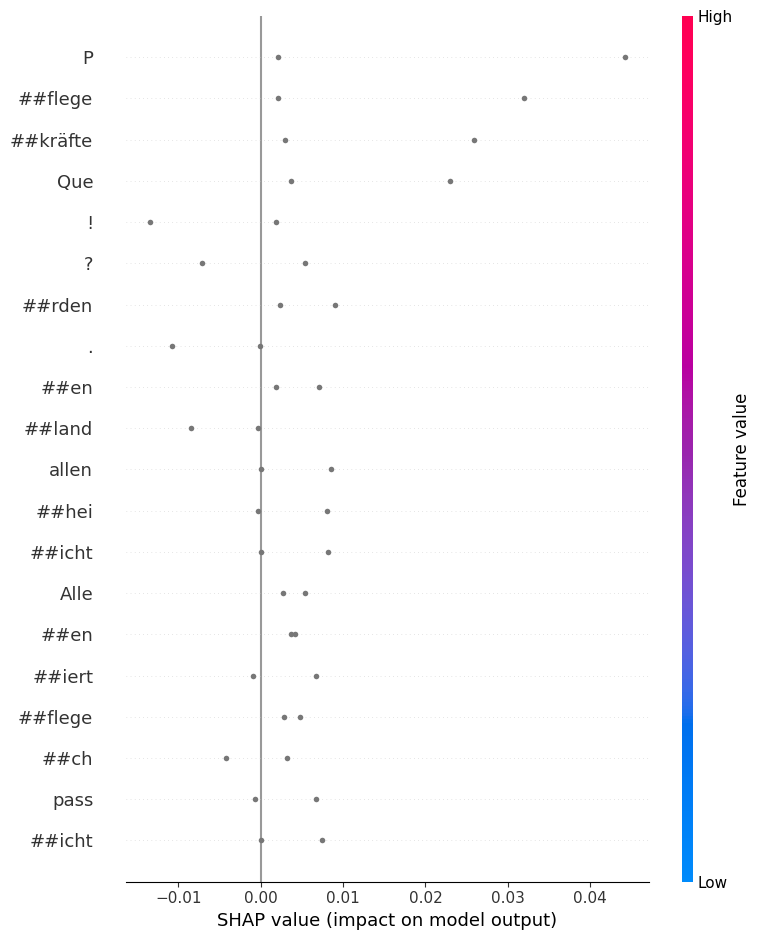


Force Plot for Sample 1: Was ist nur mit diesem Scheißland passiert? Alle werden kollektiv bekloppt und teilen Querdenen-Stuss. Erst meinen "Klatschen für die Pflegekräfte" wäre hilfreich und jetzt allen Pflegern und Medizinern so ins Gesicht spucken. Schämt euch!#allenichtganzdicht #allesdichtmachen


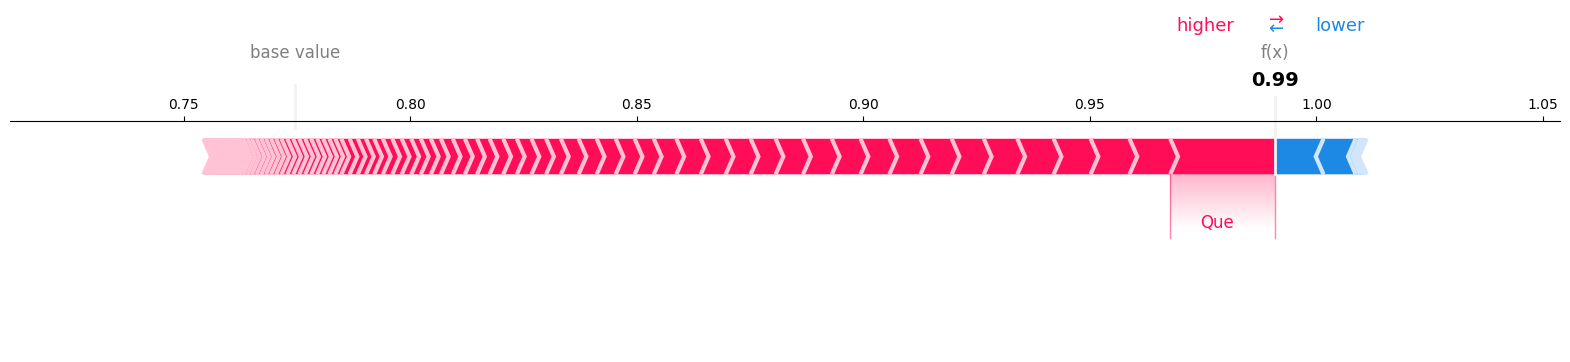


Force Plot for Sample 2:   haben schlimme Fehler begangen. Sowohl bei den Obduktionen als auch bei der Impfstoffzulassung etc. Aber gerade am Beispiel Püschel: Was haben die Querdenker draus gemacht? Die Patienten starben an Thrombosen und nicht an Covid. So dumm muss man schon sein...


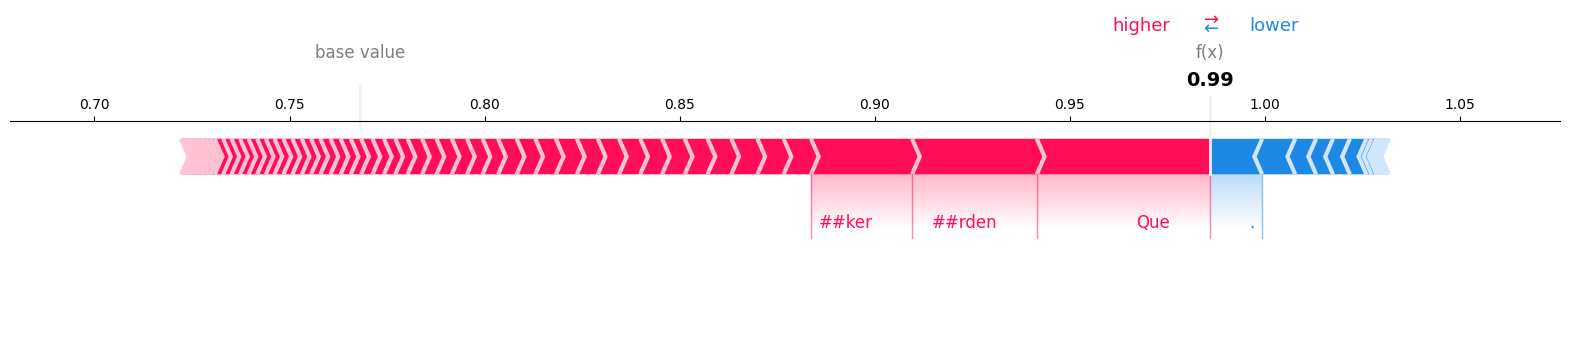


Top 10 Most Important Features (Tokens):
Token: P, Importance: 0.0232
Token: ##flege, Importance: 0.0170
Token: ##kräfte, Importance: 0.0145
Token: Que, Importance: 0.0134
Token: !, Importance: 0.0076
Token: ?, Importance: 0.0063
Token: ##rden, Importance: 0.0057
Token: ., Importance: 0.0054
Token: ##en, Importance: 0.0044
Token: ##land, Importance: 0.0044

Feature importance saved to 'feature_importance.csv'.


In [ ]:
# Install required libraries
!pip install shap transformers torch

# Import required libraries
import shap
import numpy as np
from transformers import BertTokenizerFast, BertForSequenceClassification

# Load the trained model and tokenizer
model = BertForSequenceClassification.from_pretrained("./saved_model")
tokenizer = BertTokenizerFast.from_pretrained("./saved_model")
model.to("cuda" if torch.cuda.is_available() else "cpu")

# Define predict_proba for SHAP
def predict_proba(texts):
    if isinstance(texts, str):
        texts = [texts]
    elif isinstance(texts, list) and all(isinstance(t, list) for t in texts):
        texts = [" ".join(tokens) for tokens in texts]
    elif isinstance(texts, np.ndarray):
        texts = texts.tolist()
    elif not isinstance(texts, list) or not all(isinstance(t, str) for t in texts):
        raise ValueError(f"Unexpected input format: {type(texts)}")

    inputs = tokenizer(
        texts, truncation=True, max_length=128, padding=True, return_tensors="pt"
    ).to("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.nn.functional.softmax(logits, dim=1)
    return probs.cpu().numpy()

# Initialize SHAP Explainer with Text Masker
masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_proba, masker)

# Select random sample texts from the test dataset
sample_texts = test_df.sample(2, random_state=42)["text"].tolist()

print("Sample Texts from Dataset:")
for i, text in enumerate(sample_texts, 1):
    print(f"Sample {i}: {text}")

# Compute SHAP values
shap_values = explainer(sample_texts)

# Extract Tokens and Normalize SHAP Values
tokens_list = [
    tokenizer.convert_ids_to_tokens(tokenizer(sample, truncation=True)["input_ids"])
    for sample in sample_texts
]
max_len = max(len(value.values) for value in shap_values)
normalized_shap_values = [
    np.pad(value.values[:, 1], (0, max_len - len(value.values[:, 1])), constant_values=0)
    for value in shap_values
]
normalized_tokens = [
    tokens + ['[PAD]'] * (max_len - len(tokens)) for tokens in tokens_list
]

# SHAP Summary Plot
shap.initjs()
shap.summary_plot(
    shap_values=np.array(normalized_shap_values),
    features=np.array(normalized_tokens),
    feature_names=normalized_tokens[0]
)

# SHAP Force Plot
for i, text in enumerate(sample_texts):
    print(f"\nForce Plot for Sample {i + 1}: {text}")
    shap.force_plot(
        base_value=shap_values[i].base_values[1],
        shap_values=shap_values[i].values[:, 1],
        features=tokens_list[i],
        matplotlib=True
    )

# Calculate Global Feature Importance
# Average absolute SHAP values across all samples
feature_importance = np.mean(np.abs(normalized_shap_values), axis=0)

# Combine feature importance with tokens
feature_importance_data = list(zip(normalized_tokens[0], feature_importance))

# Sort tokens by importance
sorted_feature_importance = sorted(feature_importance_data, key=lambda x: x[1], reverse=True)

# Display Top 10 Most Important Features
print("\nTop 10 Most Important Features (Tokens):")
for token, importance in sorted_feature_importance[:10]:
    print(f"Token: {token}, Importance: {importance:.4f}")

# Save Feature Importance to CSV
import csv
with open("feature_importance.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["Token", "Importance"])
    writer.writerows(sorted_feature_importance)

print("\nFeature importance saved to 'feature_importance.csv'.")
